<a href="https://colab.research.google.com/github/JosegregTovar/GOOGLE-COLLAB/blob/main/Actividad6FE_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE: ---------------------------------------------------------
*   MATRÍCULA: ----------------------------------------------------

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Instalar las bibliotecas necesarias
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.7 MB/s eta 0:00:00


In [2]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Paleta de colores para el ejercicio

violet_palette = [
    "#2E003E",  # violeta oscuro profundo
    "#4B0082",  # índigo
    "#6A0DAD",  # violeta fuerte
    "#8A2BE2",  # blue violet
    "#9370DB",  # medium purple
    "#BA55D3",  # medium orchid
    "#D8BFD8",  # thistle
]

PRIMARY_VIOLET = "#6A0DAD"
SOFT_VIOLET = "#9370DB"
DARK_VIOLET = "#2E003E"

# Aplicar paleta por defecto a seaborn
sns.set_palette(violet_palette)

# Estilo general
sns.set_style("whitegrid")

# Ajustes globales de matplotlib
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["axes.titleweight"] = "bold"

1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [5]:
compu_df = pd.read_csv("/content/drive/MyDrive/01 Analisis de Datos/ACTIVIDAD 6/computer_prices.csv")
compu_df_copy = compu_df.copy() #crear una copia por si acaso

In [6]:
compu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int64  
 15  ram_gb            

Resultado:

1.   Total 27 columnas
2. float64(3)
3.  int64(12)
4. object(12)




In [7]:
# Ver las primeras filas
compu_df.head()



,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,1024,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,512,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,512,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,512,2,IPS,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,256,1,Mini-LED,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [8]:
# Columnas numericas
num_cols = compu_df.select_dtypes(include=['int64', 'float64']).columns

# Columnas categoricas
cat_cols = compu_df.select_dtypes(include=['object']).columns

print("Columnas numericas:", len(num_cols))
print("Columnas categoricas:", len(cat_cols))

Columnas numericas: 15
Columnas categoricas: 12


In [9]:
#valores unicos por columna
unique_values = compu_df.nunique().sort_values(ascending=False)

unique_values

,0
model,99036
cpu_model,26971
price,3366
gpu_model,49
weight_kg,47
cpu_threads,25
ram_gb,15
cpu_cores,12
brand,10
form_factor,10


In [10]:
#Eliminamos las variables con mucha cardinalidad

compu_df.drop(columns=['model', 'cpu_model'], inplace=True)

compu_df.head()

,device_type,brand,release_year,os,form_factor,cpu_brand,cpu_tier,cpu_cores,cpu_threads,gpu_brand,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,2022,Windows,ATX,Intel,3,12,24,NVIDIA,...,1024,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,2022,Windows,Mainstream,Intel,4,12,24,NVIDIA,...,512,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,2024,macOS,SFF,AMD,2,8,16,NVIDIA,...,512,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,2024,Windows,ATX,AMD,2,6,12,AMD,...,512,2,IPS,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,2024,Linux,Gaming,AMD,5,16,32,NVIDIA,...,256,1,Mini-LED,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

In [11]:
#Para duplicados
duplicados = compu_df.duplicated().sum()
print("Cantidad de registros duplicados:", duplicados)

Cantidad de registros duplicados: 0


No hay valores duplicados, no se elimina nada

In [12]:
#Para faltantes

missing_values = compu_df.isnull().sum()

missing_values[missing_values > 0]

,0


Tampoco hay faltantes

In [13]:
# Primero Definir variables numéricas y categóricas

num_cols = compu_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = compu_df.select_dtypes(include=['object']).columns.tolist()

print("Columnas numéricas:")
display(pd.DataFrame(num_cols, columns=["Numéricas"]))

print("Columnas categóricas:")
display(pd.DataFrame(cat_cols, columns=["Categóricas"]))

Columnas numéricas:


,Numéricas
0,release_year
1,cpu_tier
2,cpu_cores
3,cpu_threads
4,gpu_tier
5,vram_gb
6,ram_gb
7,storage_gb
8,storage_drive_count
9,charger_watts


Columnas categóricas:


,Categóricas
0,device_type
1,brand
2,os
3,form_factor
4,cpu_brand
5,gpu_brand
6,gpu_model
7,storage_type
8,display_type
9,wifi


In [14]:
# Valores únicos por columna


unique_df = compu_df.nunique().reset_index()
unique_df.columns = ["Columna", "Valores únicos"]
unique_df = unique_df.sort_values("Valores únicos", ascending=False) #para ver los que tienen mas valores

display(unique_df)

,Columna,Valores únicos
24,price,3366
10,gpu_model,49
22,weight_kg,47
8,cpu_threads,25
13,ram_gb,15
7,cpu_cores,12
1,brand,10
4,form_factor,10
19,psu_watts,9
2,release_year,8


In [15]:
# Ahora vamos con las Estadísticas numéricas

display(compu_df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
release_year,100000.0,2022.320850,2.025761,2018.00,2021.00,2023.00,2024.00,2025.00
cpu_tier,100000.0,3.153490,1.373175,1.00,2.00,3.00,4.00,6.00
cpu_cores,100000.0,10.515740,5.044092,4.00,6.00,8.00,14.00,28.00
cpu_threads,100000.0,19.372700,9.718426,4.00,12.00,16.00,24.00,56.00
gpu_tier,100000.0,2.991350,1.459643,1.00,2.00,3.00,4.00,6.00
vram_gb,100000.0,6.152180,3.964926,0.00,4.00,6.00,8.00,16.00
ram_gb,100000.0,39.706400,31.902684,8.00,16.00,32.00,64.00,144.00
storage_gb,100000.0,903.936000,774.243654,256.00,512.00,512.00,1024.00,4096.00
storage_drive_count,100000.0,1.524980,0.797284,1.00,1.00,1.00,2.00,4.00
charger_watts,100000.0,61.383450,62.795034,0.00,0.00,65.00,90.00,240.00


In [16]:

# Estadísticas categóricas

display(compu_df[cat_cols].describe().T)

,count,unique,top,freq
device_type,100000,2,Laptop,59844
brand,100000,10,Lenovo,15992
os,100000,4,Windows,71817
form_factor,100000,10,Mainstream,17819
cpu_brand,100000,3,Intel,52774
gpu_brand,100000,4,NVIDIA,54712
gpu_model,100000,49,Apple Integrated,18922
storage_type,100000,4,NVMe,45059
display_type,100000,6,LED,32000
wifi,100000,4,Wi-Fi 6,46149


In [17]:
# Tablas de frecuencia para categóricas

for col in cat_cols:

    print(f"\n🔹 Frecuencia - {col}")

    freq_table = compu_df[col].value_counts().head(10).reset_index()
    freq_table.columns = [col, "Frecuencia"]

    display(freq_table)


🔹 Frecuencia - device_type


,device_type,Frecuencia
0,Laptop,59844
1,Desktop,40156



🔹 Frecuencia - brand


,brand,Frecuencia
0,Lenovo,15992
1,HP,14114
2,Dell,14005
3,Apple,11915
4,ASUS,10159
5,Acer,9925
6,Samsung,8066
7,MSI,7891
8,Gigabyte,4900
9,Razer,3033



🔹 Frecuencia - os


...

,storage_type,Frecuencia
0,NVMe,45059
1,SSD,24937
2,HDD,15023
3,Hybrid,14981



🔹 Frecuencia - display_type


,display_type,Frecuencia
0,LED,32000
1,OLED,21910
2,IPS,17742
3,Mini-LED,12188
4,QLED,10069
5,VA,6091



🔹 Frecuencia - wifi


,wifi,Frecuencia
0,Wi-Fi 6,46149
1,Wi-Fi 6E,25923
2,Wi-Fi 5,19926
3,Wi-Fi 7,8002


# Histogramas

## *  Numéricos




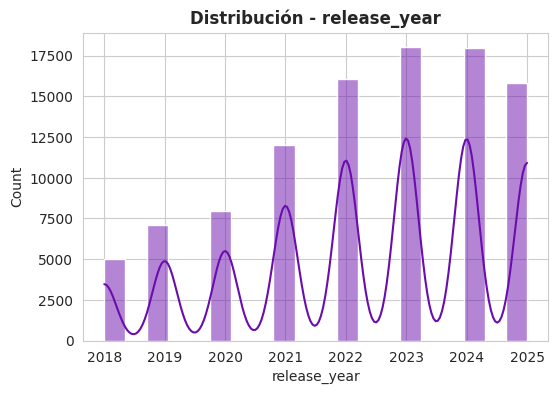

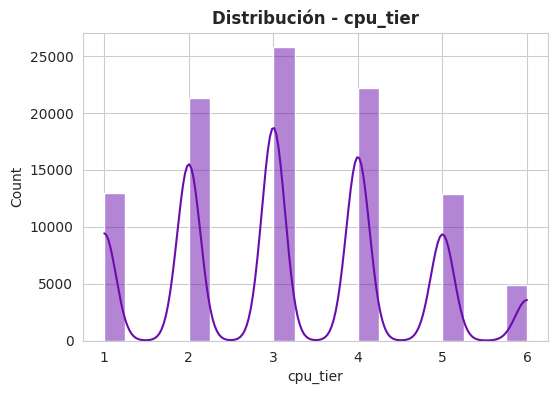

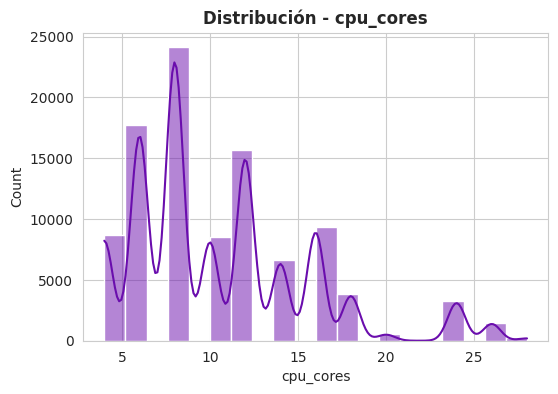

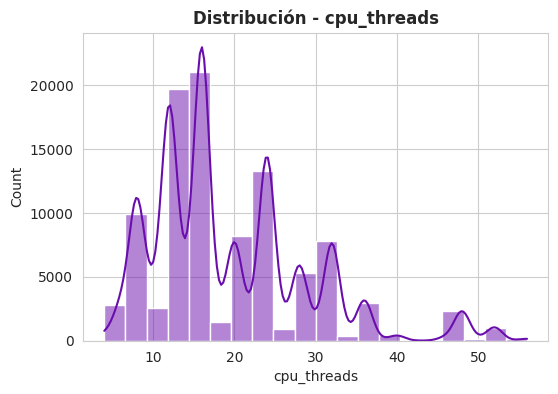

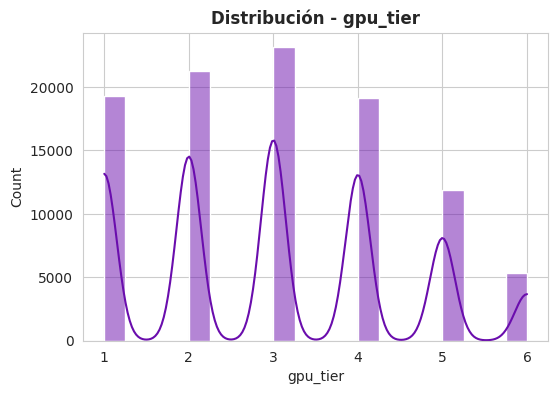

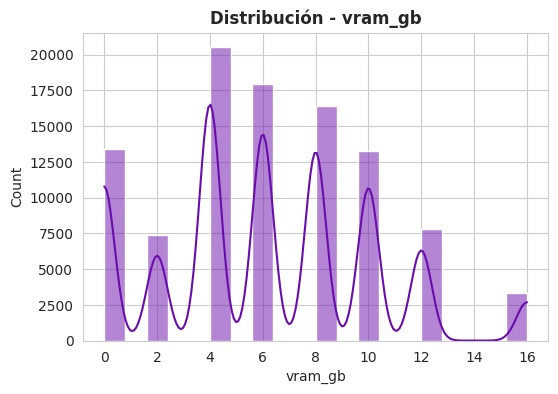

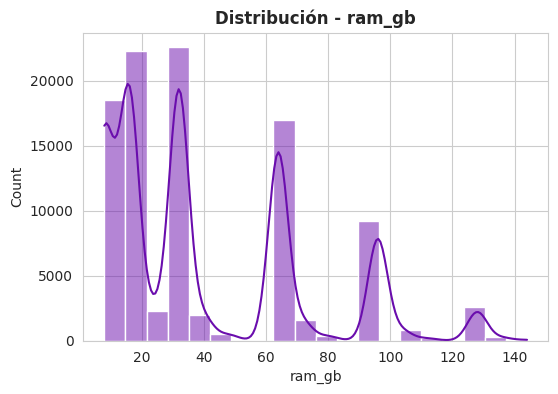

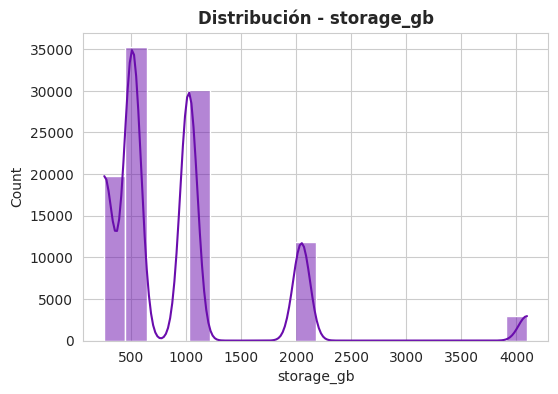

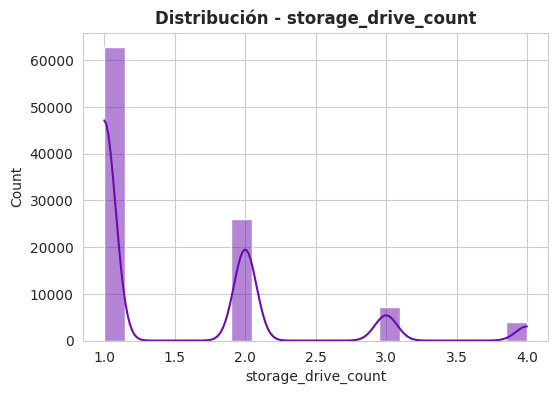

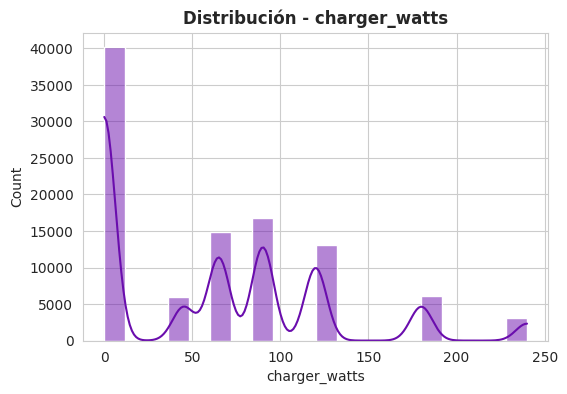

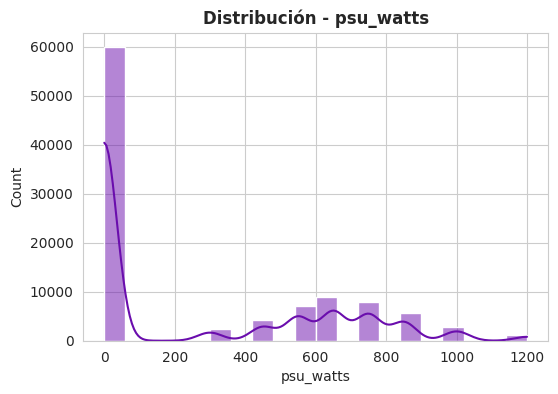

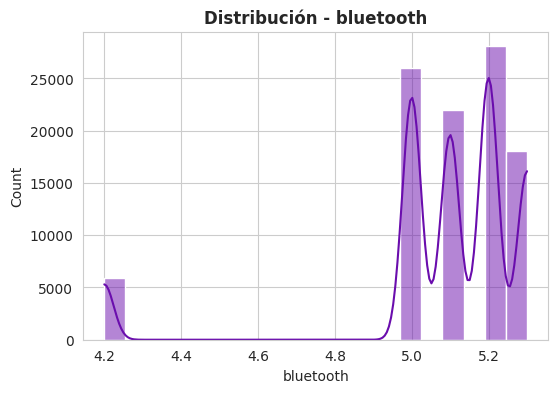

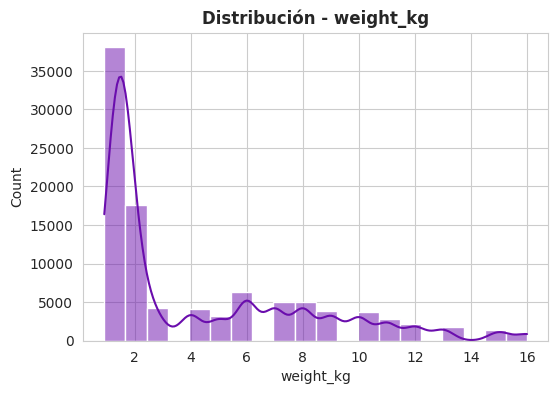

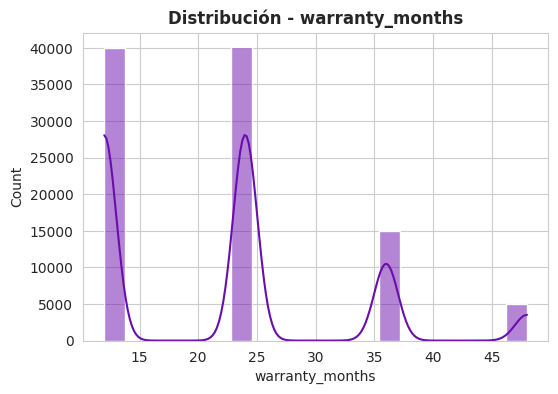

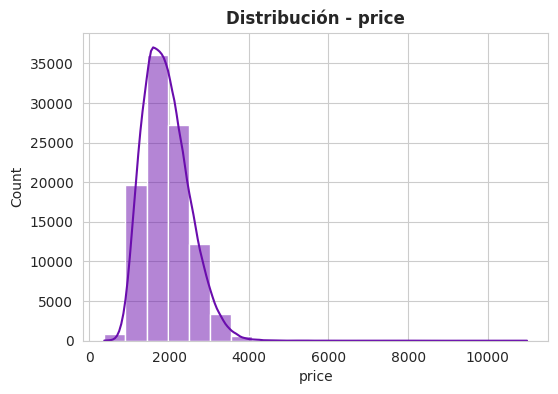

In [18]:
# Histogramas numéricos

for col in num_cols:

    plt.figure()

    sns.histplot(
        compu_df[col],
        bins=20,
        kde=True,
        color=PRIMARY_VIOLET,
        edgecolor="white"
    )

    plt.title(f"Distribución - {col}")
    plt.show()



## *   Categóricas



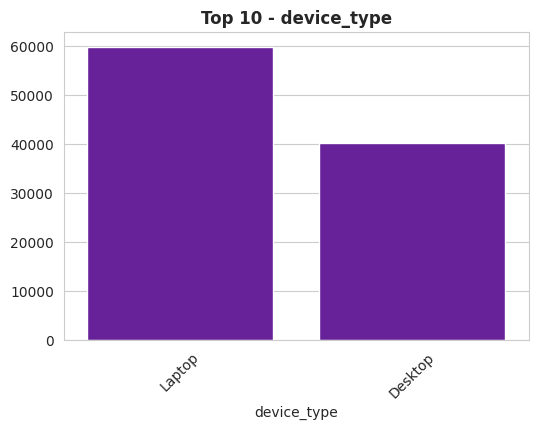

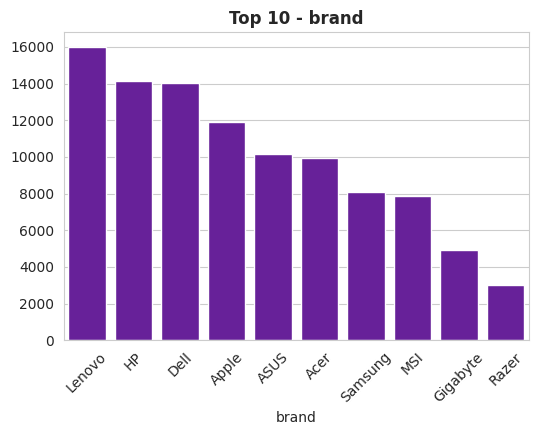

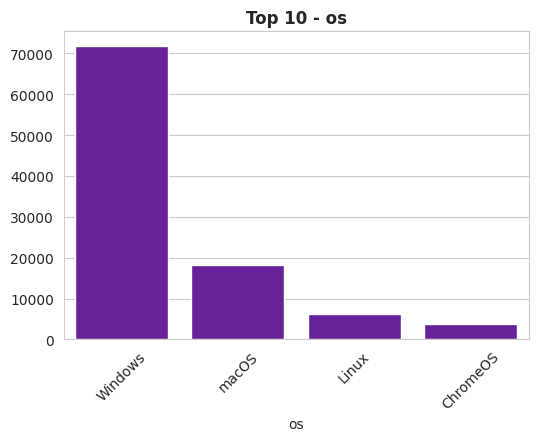

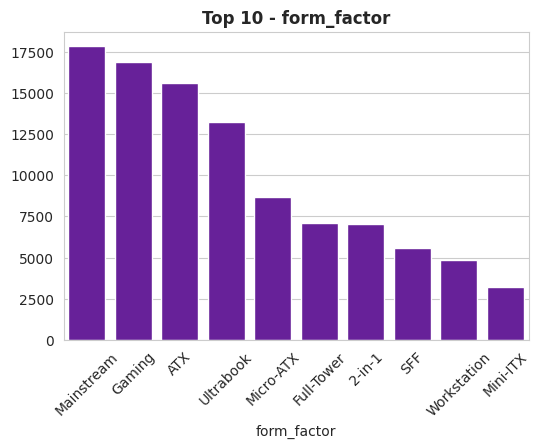

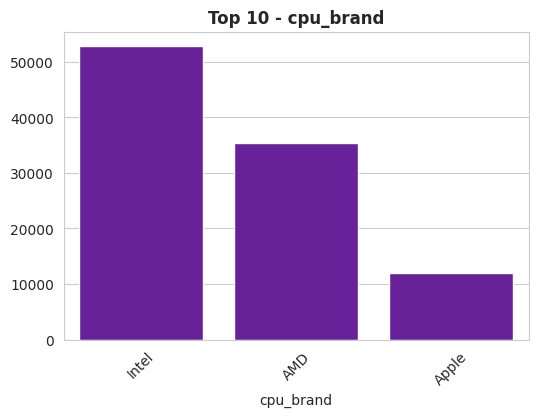

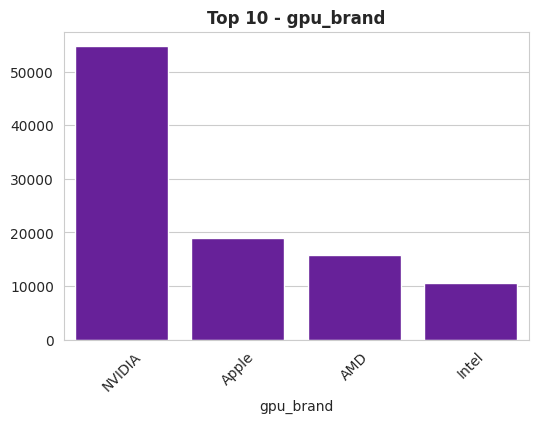

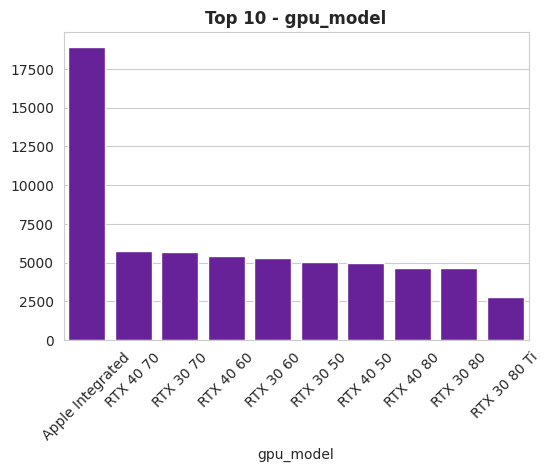

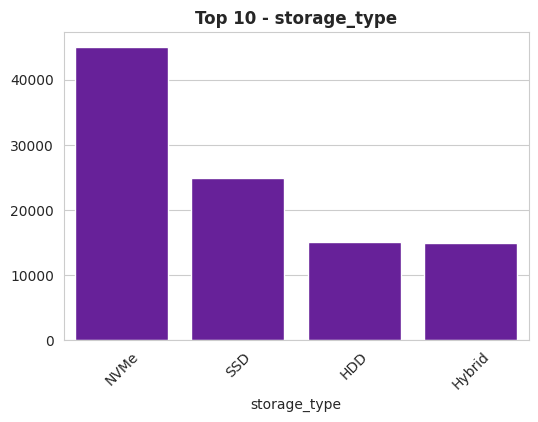

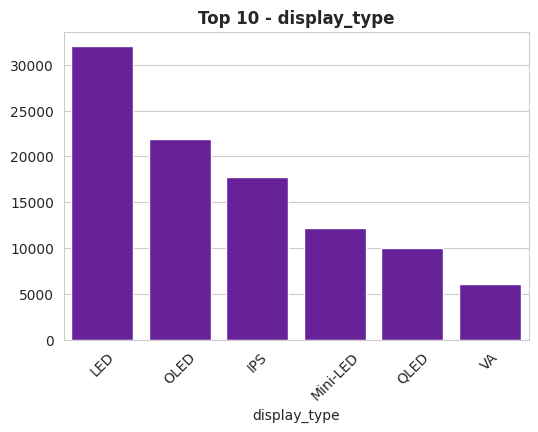

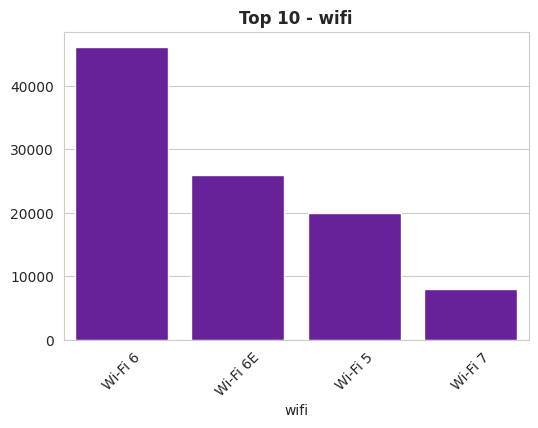

In [19]:
for col in cat_cols:

    plt.figure()

    top_values = compu_df[col].value_counts().head(10)

    sns.barplot(
        x=top_values.index,
        y=top_values.values,
        color=PRIMARY_VIOLET
    )

    plt.title(f"Top 10 - {col}")
    plt.xticks(rotation=45)
    plt.show()

3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

In [20]:
# Matriz de correlación

corr_matrix = compu_df[num_cols].corr()

display(corr_matrix)

,release_year,cpu_tier,cpu_cores,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
release_year,1.000000,-0.003788,-0.002468,-0.003357,-0.002626,-0.005210,-0.002416,-0.003399,0.000310,-0.000639,-0.001268,0.002489,-0.000905,-0.004031,0.089721
cpu_tier,-0.003788,1.000000,0.937376,0.848197,0.857225,0.409049,0.899349,0.001006,-0.004603,0.003966,-0.005501,-0.001991,-0.004079,0.000008,0.759196
cpu_cores,-0.002468,0.937376,1.000000,0.898171,0.812393,0.380896,0.906770,0.001004,0.016125,-0.028873,0.032949,-0.000568,0.030376,0.000015,0.720464
cpu_threads,-0.003357,0.848197,0.898171,1.000000,0.735096,0.556134,0.813155,0.000832,0.014963,-0.027150,0.031746,-0.002445,0.029261,0.000063,0.577503
gpu_tier,-0.002626,0.857225,0.812393,0.735096,1.000000,0.498624,0.912918,-0.003123,0.051215,-0.078105,0.090594,-0.000242,0.083700,-0.002593,0.762875
vram_gb,-0.005210,0.409049,0.380896,0.556134,0.498624,1.000000,0.441475,0.003355,0.030479,-0.044648,0.050708,-0.001494,0.046039,0.001302,0.305017
ram_gb,-0.002416,0.899349,0.906770,0.813155,0.912918,0.441475,1.000000,-0.001190,0.023607,-0.039456,0.045059,-0.000578,0.042133,-0.002225,0.758654
storage_gb,-0.003399,0.001006,0.001004,0.000832,-0.003123,0.003355,-0.001190,1.000000,0.001392,0.002160,-0.004137,0.000408,-0.004279,-0.004392,0.088937
storage_drive_count,0.000310,-0.004603,0.016125,0.014963,0.051215,0.030479,0.023607,0.001392,1.000000,-0.426559,0.500057,0.002185,0.454040,-0.003646,-0.082437
charger_watts,-0.000639,0.003966,-0.028873,-0.027150,-0.078105,-0.044648,-0.039456,0.002160,-0.426559,1.000000,-0.751078,-0.001489,-0.686176,0.005589,0.126309


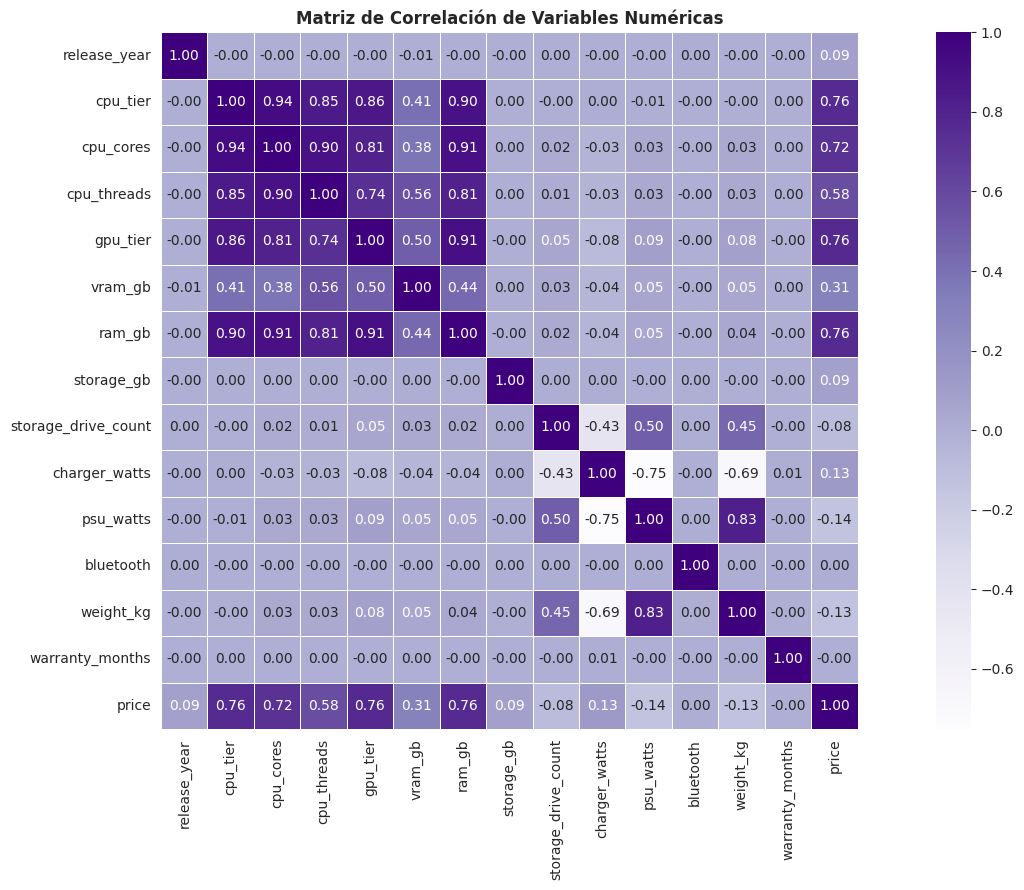

In [21]:
# Heatmap de correlación

plt.figure(figsize=(16,9))

sns.heatmap(
    corr_matrix,
    cmap="Purples",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Matriz de Correlación de Variables Numéricas")
plt.tight_layout()
plt.show()

In [24]:
# Para no hacerlo solo visual ahora a Detectar correlaciones > 0.9


lim_min = 0.9

high_corr_par = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):

        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > lim_min:
            high_corr_par.append((col1, col2, corr_value))

high_corr_df = pd.DataFrame(
    high_corr_par,
    columns=["Variable 1", "Variable 2", "Correlación"]
)

display(high_corr_df)

,Variable 1,Variable 2,Correlación
0,cpu_cores,cpu_tier,0.937376
1,ram_gb,cpu_cores,0.906770
2,ram_gb,gpu_tier,0.912918


**Reflexión: **

El análisis de correlación mostró que el par con mayor asociación fue: cpu_cores  y cpu_tier (r = 0.937)

Considero que esta correlación indica que ambas variables contienen practicamente la misma información, pero representada en escalas diferentes:

- cpu_cores es una medida directa, cuantitativa y física del hardware.

- cpu_tier es una clasificación ordinal derivada, que resume el desempeño del procesador en una escala del 1 al 6.

En términos de ingeniería de datos, esto implica que cpu_tier es una variable transformada o resumida que ya está implcitamente contenida en cpu_cores.

Cuando dos variables presentan correlaciones superiores a 0.9, existe alta redundancia informativa y mantener ambas incrementa la multicolinealidad (No aporta información nueva al modelo).

Por eso decido eliminar: cpu_tier

In [25]:
compu_df.drop(columns=["cpu_tier"], inplace=True)

In [26]:
#actualizamos las listas

num_cols = compu_df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = compu_df.select_dtypes(include=['object']).columns.tolist()

4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_transf`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un histograma para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

In [27]:
#Crear copia para transformaciones

compu_transf = compu_df.copy()

display(compu_transf.head())

,device_type,brand,release_year,os,form_factor,cpu_brand,cpu_cores,cpu_threads,gpu_brand,gpu_model,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,2022,Windows,ATX,Intel,12,24,NVIDIA,RTX 40 60,...,1024,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,2022,Windows,Mainstream,Intel,12,24,NVIDIA,RTX 40 80,...,512,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,2024,macOS,SFF,AMD,8,16,NVIDIA,RTX 40 50,...,512,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,2024,Windows,ATX,AMD,6,12,AMD,RX 7000 60,...,512,2,IPS,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,2024,Linux,Gaming,AMD,16,32,NVIDIA,RTX 30 80 Ti,...,256,1,Mini-LED,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


**Años de Lanzamiento**

In [28]:
# Calcular años desde lanzamiento

from datetime import datetime

current_year = datetime.now().year

compu_transf["years_since_release"] = current_year - compu_transf["release_year"]

# Eliminar columna original
compu_transf.drop(columns=["release_year"], inplace=True)

display(compu_transf[["years_since_release"]].head())

,years_since_release
0,4
1,4
2,2
3,2
4,2


**Discretizacion en cuantiles**

In [29]:


# Instanciar discretizador
kbins = KBinsDiscretizer(
    n_bins=4,
    encode="ordinal",
    strategy="quantile"
)

# Ajustar
kbins.fit(compu_transf[["vram_gb"]])

# Transformar
compu_transf["vram_bins"] = kbins.transform(
    compu_transf[["vram_gb"]]
)

# Convertir a entero y que comience en 1 y no en cero

compu_transf["vram_bins"] = compu_transf["vram_bins"].astype(int) + 1

display(compu_transf[["vram_gb", "vram_bins"]].head())

,vram_gb,vram_bins
0,6,3
1,10,4
2,4,2
3,6,3
4,12,4


In [30]:
#Veamos como se dividió l variable

bin_edges = kbins.bin_edges_[0]

bins_df = pd.DataFrame({
    "Bin": range(len(bin_edges)-1),
    "Desde": bin_edges[:-1],
    "Hasta": bin_edges[1:]
})

display(bins_df)

,Bin,Desde,Hasta
0,0,0.0,4.0
1,1,4.0,6.0
2,2,6.0,8.0
3,3,8.0,16.0


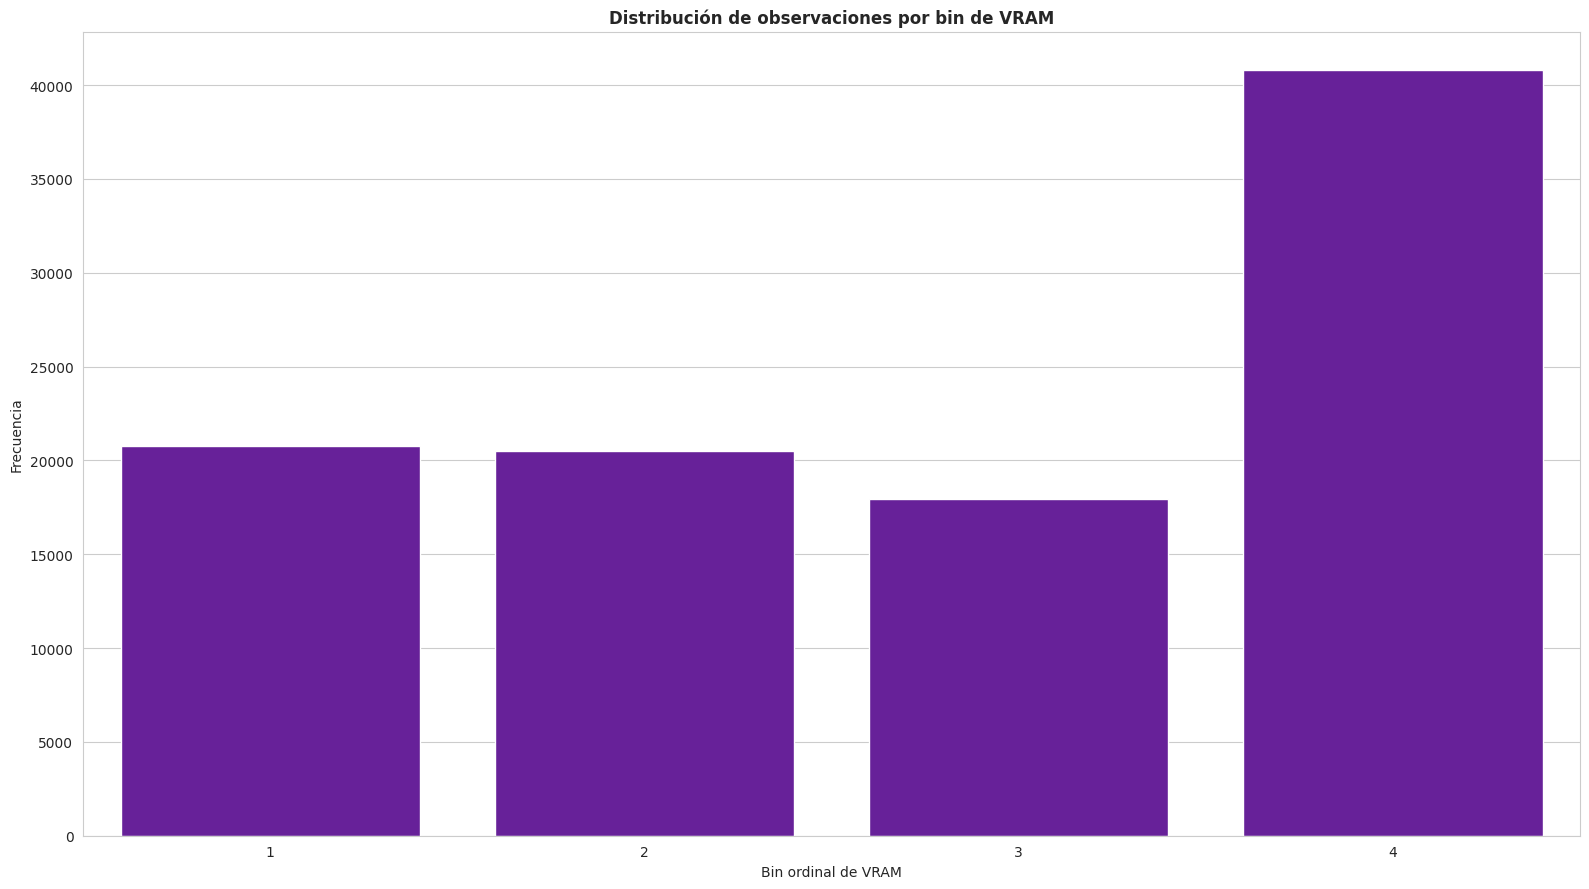

In [31]:

# Histograma de bins


plt.figure(figsize=(16,9))

sns.countplot(
    x="vram_bins",
    data=compu_transf,
    color= PRIMARY_VIOLET
)

plt.title("Distribución de observaciones por bin de VRAM")
plt.xlabel("Bin ordinal de VRAM")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

**Explicación**

Aquí la lógica es super clara y obvia: esas barras en 0 no son “datos malos” es una señal de diseño del dataset, esto viene del mismo nombre de la variable:

- charger_watts: Potencia del cargador (en watts) para laptops
- psu_watts: Potencia de la fuente de poder (en watts) para desktops

Entonces

1. Las Laptops usan charger_watts (cargador) y no tienen psu_watts, por eso queda 0 en psu_watts.

2. Las Desktops usan psu_watts (fuente de poder) y no tienen charger_watts por ende queda 0 en charger_watts.

Eso crea barras en 0 porque la variable “no aplica” al otro tipo de dispositivo. Por ende si se pueden unir ya que son totalmente excluyentes.

Igual se puede validar:

In [32]:
zeros_charger = (compu_transf["charger_watts"] == 0).sum()      # cuenta ceros en charger_watts
zeros_psu     = (compu_transf["psu_watts"] == 0).sum()          # cuenta ceros en psu_watts

display(pd.DataFrame({
    "Columna": ["charger_watts", "psu_watts"],
    "Cantidad de ceros": [zeros_charger, zeros_psu],
    "Total filas": [len(compu_transf), len(compu_transf)]
}))

# Creamos una tabla cruzada para ver ceros vs tipo de dispositivo

print("\nTabla cruzada de ceros vs tipo de dispositivo:")

cross_zeros = pd.crosstab(
    compu_transf["device_type"],                 # filas: tipo de dispositivo
    compu_transf["charger_watts"] == 0,
    normalize="index"                            # proporciones dentro de cada tipo
)


display(cross_zeros.rename(columns={False:"charger_watts > 0", True:"charger_watts = 0"}))



,Columna,Cantidad de ceros,Total filas
0,charger_watts,40156,100000
1,psu_watts,59844,100000



Tabla cruzada de ceros vs tipo de dispositivo:


charger_watts,charger_watts > 0,charger_watts = 0
device_type,,
Desktop,0.0,1.0
Laptop,1.0,0.0


In [33]:
# Repetimos el cruce para psu_watts

print("\nTabla cruzada de ceros vs tipo de dispositivo:")

cross_zeros_psu = pd.crosstab(
    compu_transf["device_type"],
    compu_transf["psu_watts"] == 0,
    normalize="index"
)

display(cross_zeros_psu.rename(columns={False:"psu_watts > 0", True:"psu_watts = 0"}))


Tabla cruzada de ceros vs tipo de dispositivo:


psu_watts,psu_watts > 0,psu_watts = 0
device_type,,
Desktop,1.0,0.0
Laptop,0.0,1.0


In [34]:
#COmo ya vimos que si son independientes:

# CREAMOS power_watts COMBINANDO charger_watts y psu_watts, con la logica de:
#   Si charger_watts es mayor que 0, usar charger_watts
#   Si no, usar psu_watts

compu_transf["power_watts"] = np.where(
    compu_transf["charger_watts"] > 0,
    compu_transf["charger_watts"],              # si se cumple: usamos charger
    compu_transf["psu_watts"]
)


# Mostramos algunas filas para verificar que se construyó bien

display(compu_transf[["device_type","charger_watts","psu_watts","power_watts"]].head(10))


,device_type,charger_watts,psu_watts,power_watts
0,Desktop,0,750,750
1,Laptop,120,0,120
2,Desktop,0,850,850
3,Desktop,0,650,650
4,Laptop,90,0,90
5,Desktop,0,1000,1000
6,Desktop,0,850,850
7,Desktop,0,650,650
8,Laptop,240,0,240
9,Laptop,45,0,45


In [35]:

# Validación rápida (NO debería haber power_watts en 0)

zeros_power = (compu_transf["power_watts"] == 0).sum()
display(pd.DataFrame({"Ceros en power_watts":[zeros_power]}))

,Ceros en power_watts
0,0


## **Histogramas**

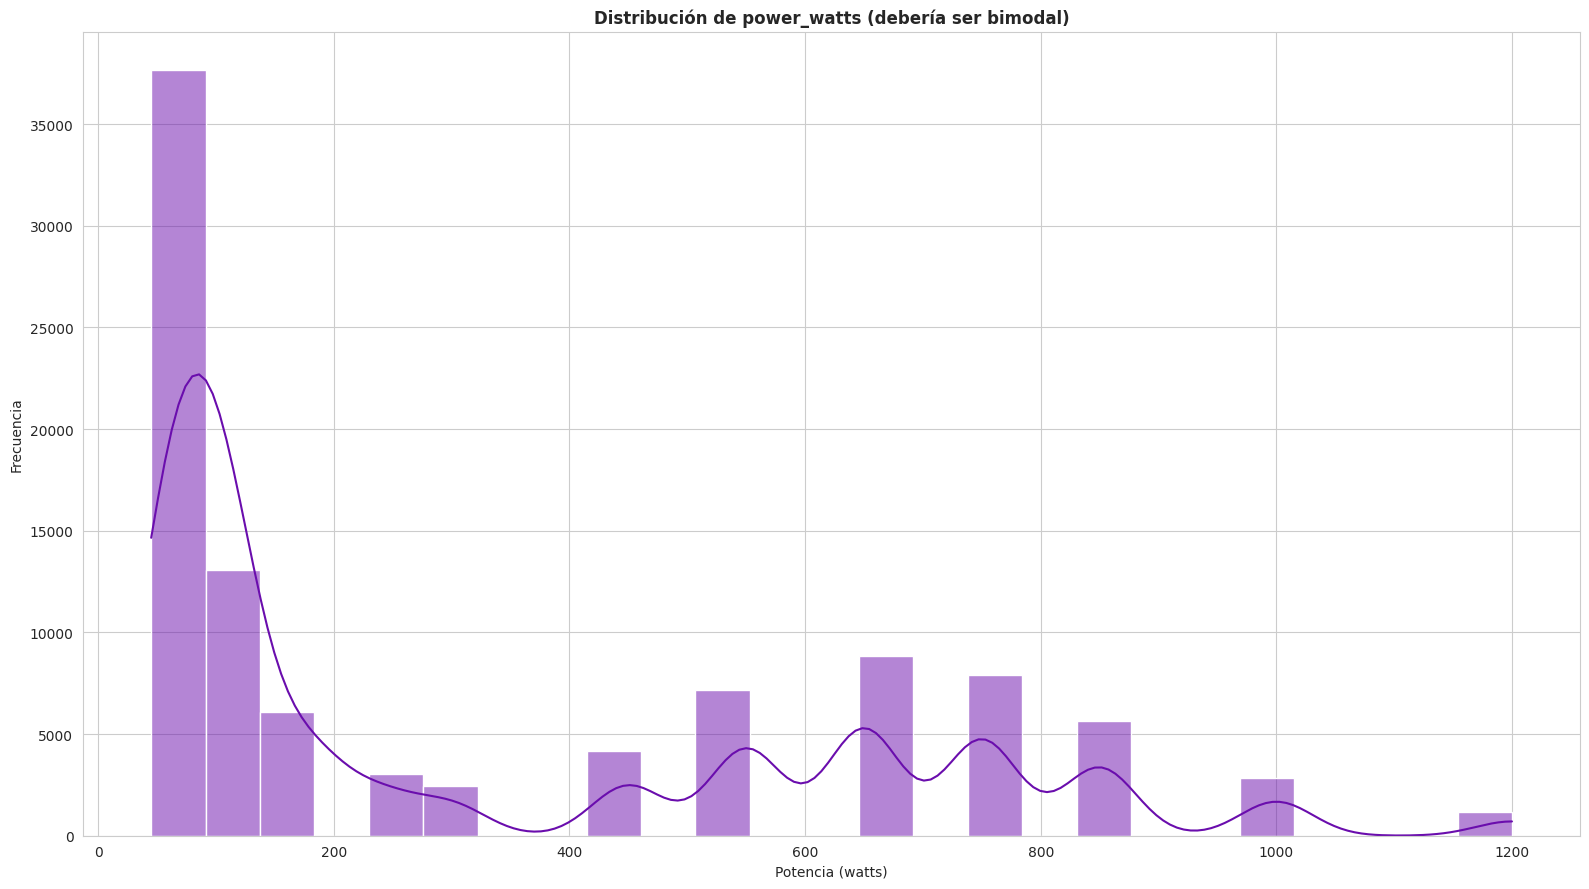

In [36]:
# HISTOGRAMA: power_watts (esperamos bimodalidad)

plt.figure(figsize=(16,9))

sns.histplot(
    data=compu_transf,
    x="power_watts",
    bins=25,
    kde=True,
    color= PRIMARY_VIOLET,
    edgecolor="white"
)

plt.title("Distribución de power_watts (debería ser bimodal)")
plt.xlabel("Potencia (watts)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

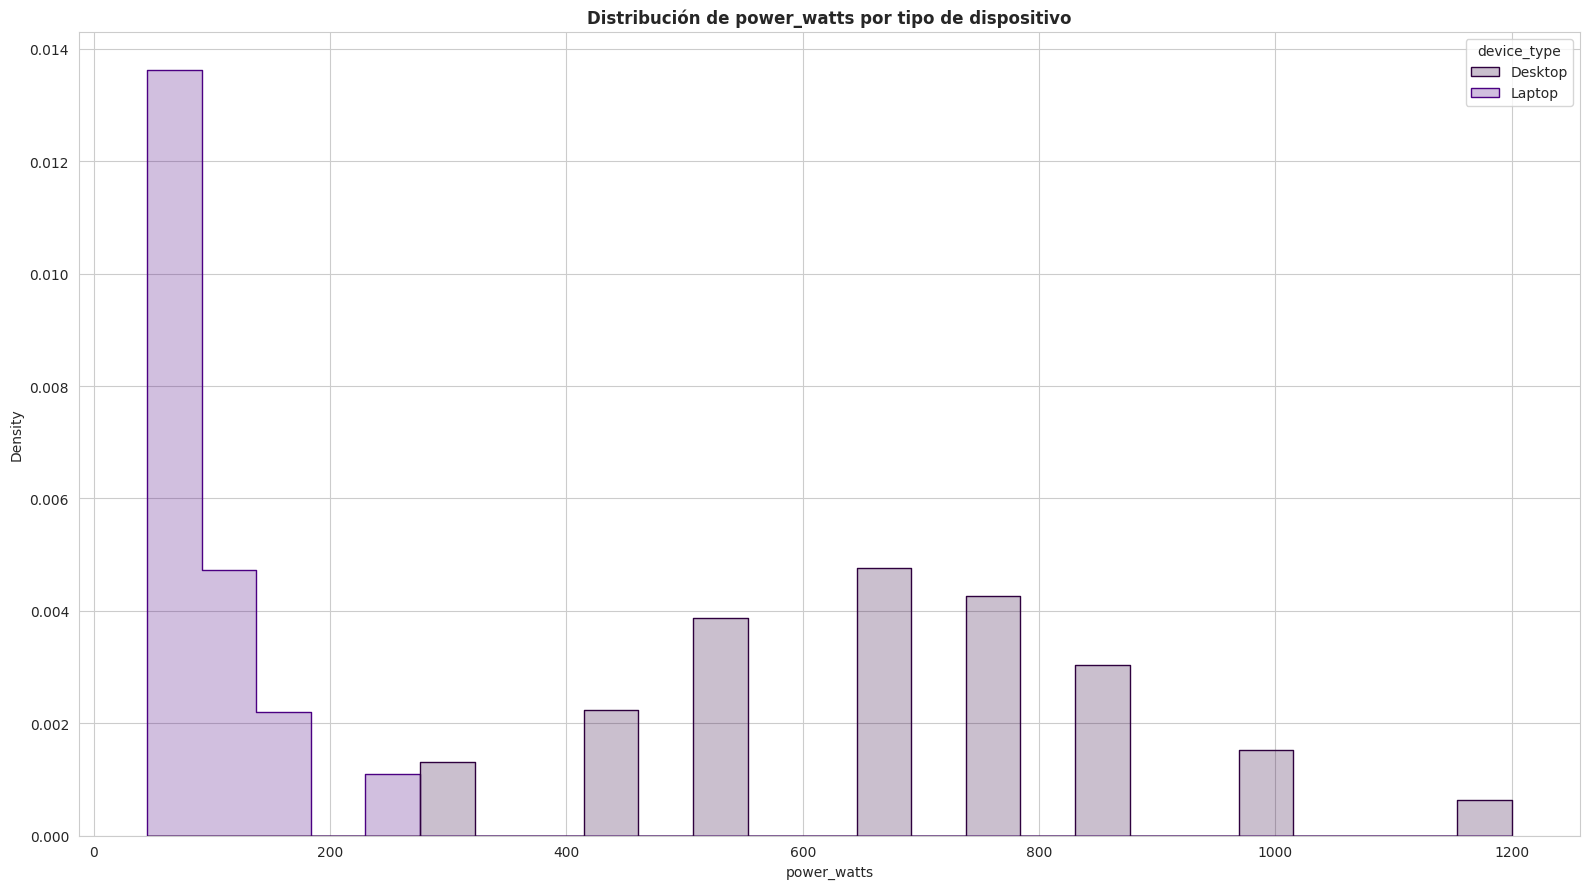

In [37]:
# Como no me quedaba tan claro quise Confirmar visualmente la bimodalidad por tipo


plt.figure(figsize=(16,9))

sns.histplot(
    data=compu_transf,
    x="power_watts",
    hue="device_type",     # separa por laptop de desktop
    bins=25,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Distribución de power_watts por tipo de dispositivo")
plt.tight_layout()
plt.show()

In [38]:

# Por ultimo Eliminamos columnas originales

compu_transf.drop(columns=["charger_watts","psu_watts"], inplace=True)


# Verificamos que ya no existen

display(pd.DataFrame({"Columnas actuales": compu_transf.columns}))

,Columnas actuales
0,device_type
1,brand
2,os
3,form_factor
4,cpu_brand
5,cpu_cores
6,cpu_threads
7,gpu_brand
8,gpu_model
9,gpu_tier


6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.

In [39]:
# Como muchas formulas dependen de datos positivos validemos que sean correctos

display(pd.DataFrame({
    "Mínimo price": [compu_transf["price"].min()]
}))

,Mínimo price
0,372.99


In [40]:

# Creemos transformaciones temporales

from scipy import stats

# Logaritmo natural

price_log = np.log(compu_transf["price"])


# Raíz cuadrada

price_sqrt = np.sqrt(compu_transf["price"])


# Box-Cox

price_boxcox, lambda_opt = stats.boxcox(compu_transf["price"])

display(pd.DataFrame({"Lambda óptimo Box-Cox":[lambda_opt]}))             # Mostrar lambda óptimo

,Lambda óptimo Box-Cox
0,0.150418


In [41]:
#Veamos como quedaron

price_compare_df = pd.DataFrame({
    "price_original": compu_transf["price"],
    "price_log": price_log,
    "price_sqrt": price_sqrt,
    "price_boxcox": price_boxcox
})

display(price_compare_df.head(10))

,price_original,price_log,price_sqrt,price_boxcox
0,1383.99,7.232726,37.202016,13.084409
1,2274.99,7.729731,47.696855,14.616126
2,1879.99,7.539022,43.358851,14.014803
3,1331.99,7.194429,36.496438,12.971066
4,2681.99,7.894314,51.787933,15.149121
5,2751.99,7.920080,52.459413,15.233762
6,1609.99,7.383983,40.124681,13.538507
7,2139.99,7.668556,46.260026,14.421355
8,2953.99,7.990912,54.350621,15.468149
9,1653.99,7.410946,40.669276,13.620543


In [44]:
#Creamos una función para mayor repetitibilidad del cálculo:

def evaluar_transformacion(data, nombre):

    print(f"\n*****************************")
    print(f"Evaluando: {nombre}")
    print(f"*****************************\n")

    # 1 Histograma
    print('\n HISTOGRAMA')
    plt.figure(figsize=(7,4))
    sns.histplot(data, bins=30, kde=True, color=PRIMARY_VIOLET)
    plt.title(f"Histograma - {nombre}")
    plt.show()

    # 2 Boxplot
    print('\n BOXPLOT')

    plt.figure(figsize=(7,2))
    sns.boxplot(x=data, color=SOFT_VIOLET)
    plt.title(f"Boxplot - {nombre}")
    plt.show()


    # 3 Q-Q plot
    print('\n Q-Q PLOT')

    plt.figure(figsize=(7,7))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot - {nombre}")
    plt.show()

    # 4 Skew
    print('\n SKEW')

    skew_value = stats.skew(data)



    # 5 Outliers (método IQR)
    print('\n OUTLIERS')

    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((data < lower_bound) | (data > upper_bound)).sum()
    outlier_pct = (outliers / len(data)) * 100

    # Mostrar métricas

    print("\n Métricas de Distribución")


# Clasificación del skew
    if abs(skew_value) < 0.5:
        skew_label = "Aproximadamente simétrica"
    elif abs(skew_value) < 1:
        skew_label = "Moderadamente sesgada"
    else:
        skew_label = "Altamente sesgada"

    print(f"🔹 Skew: {skew_value:.4f}  es  {skew_label}")
    print(f"🔹 Outliers: {outliers} ({outlier_pct:.2f}%)")



*****************************
Evaluando: Original
*****************************


 HISTOGRAMA


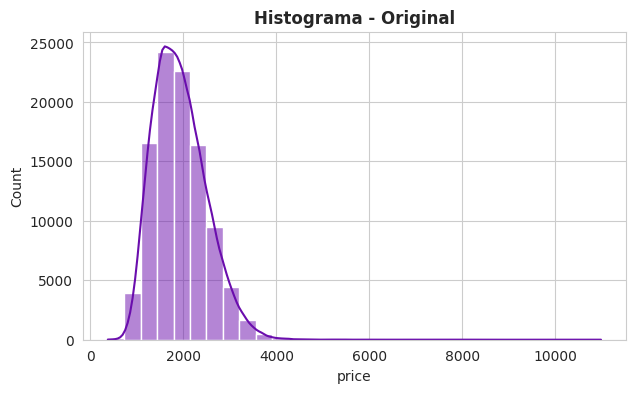


 BOXPLOT


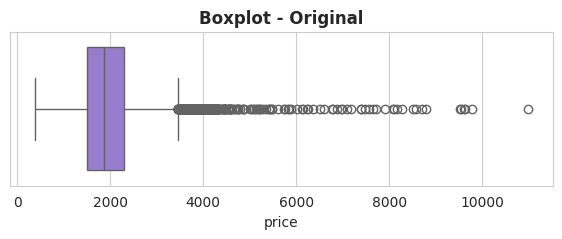


 Q-Q PLOT


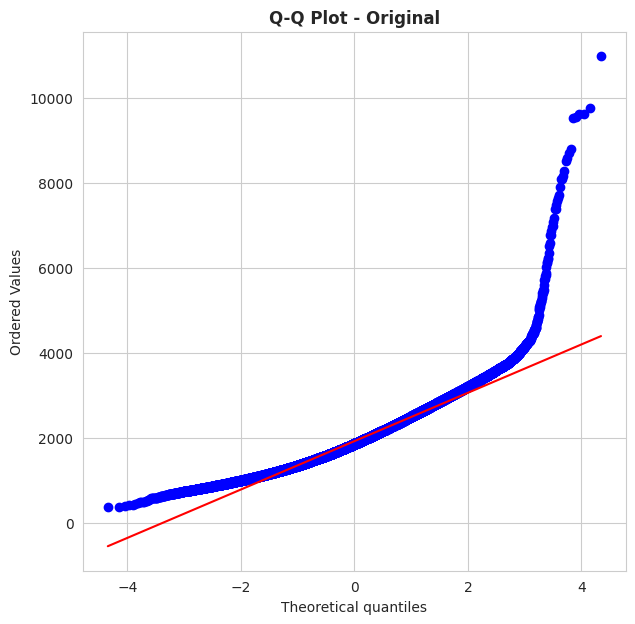


 SKEW

 OUTLIERS

 Métricas de Distribución
🔹 Skew: 0.9866  es  Moderadamente sesgada
🔹 Outliers: 976 (0.98%)



*****************************
Evaluando: Log
*****************************


 HISTOGRAMA


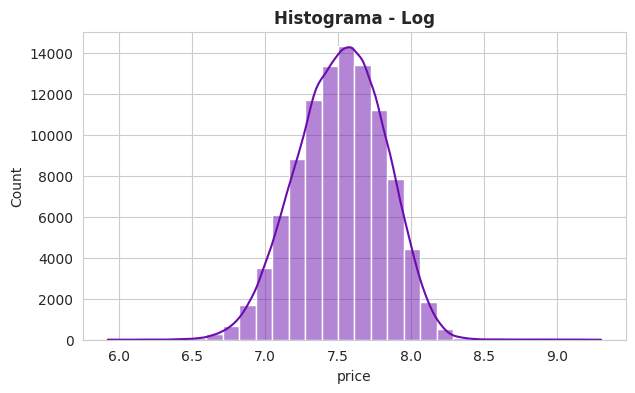


 BOXPLOT


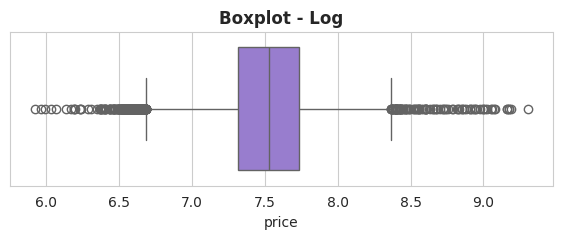


 Q-Q PLOT


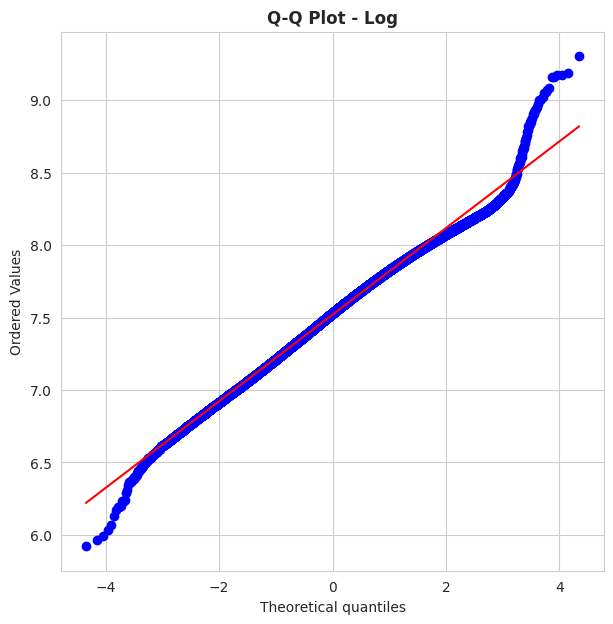


 SKEW

 OUTLIERS

 Métricas de Distribución
🔹 Skew: -0.1331  es  Aproximadamente simétrica
🔹 Outliers: 386 (0.39%)



*****************************
Evaluando: Raíz Cuadrada
*****************************


 HISTOGRAMA


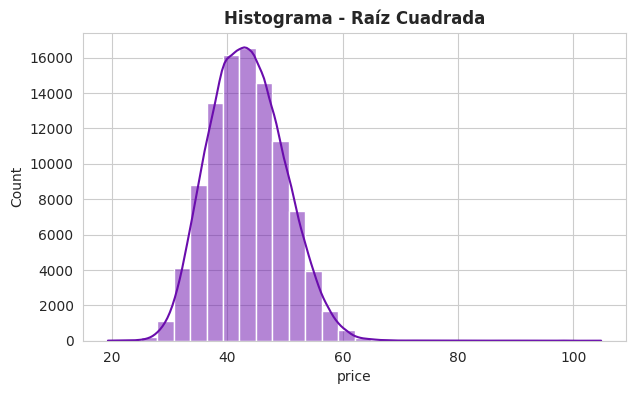


 BOXPLOT


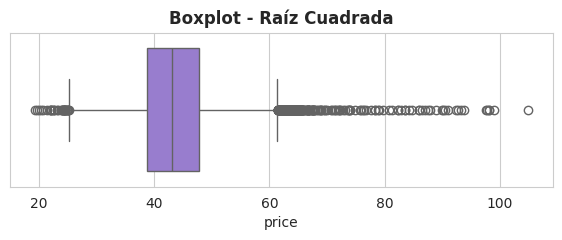


 Q-Q PLOT


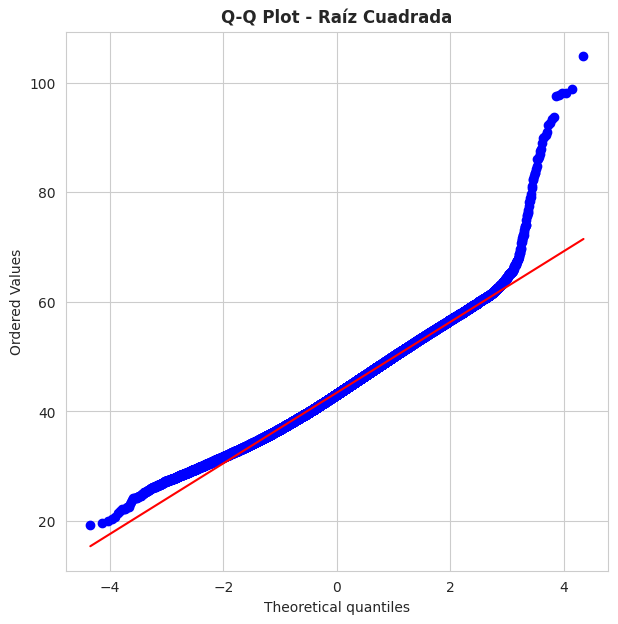


 SKEW

 OUTLIERS

 Métricas de Distribución
🔹 Skew: 0.3322  es  Aproximadamente simétrica
🔹 Outliers: 364 (0.36%)



*****************************
Evaluando: Box-Cox
*****************************


 HISTOGRAMA


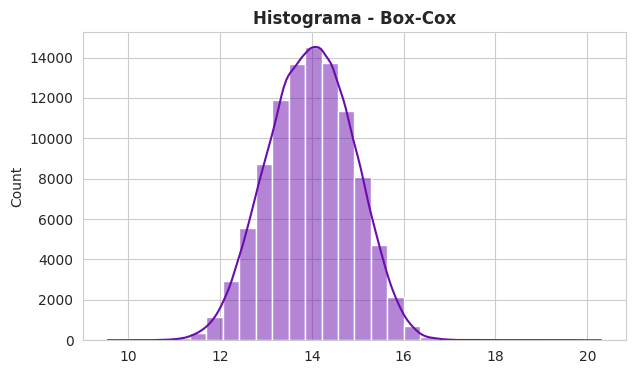


 BOXPLOT


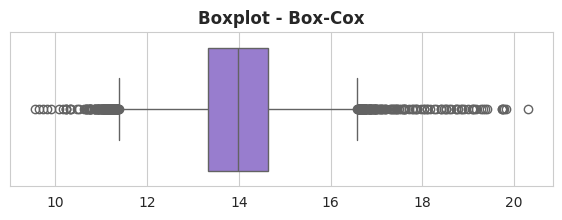


 Q-Q PLOT


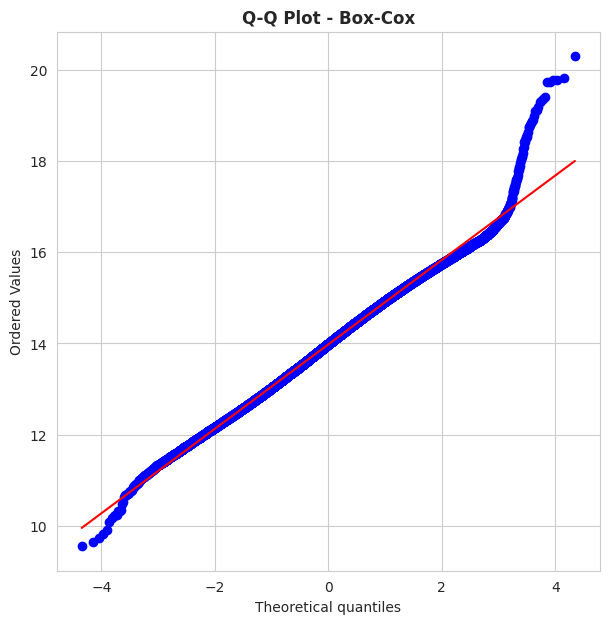


 SKEW

 OUTLIERS

 Métricas de Distribución
🔹 Skew: -0.0002  es  Aproximadamente simétrica
🔹 Outliers: 317 (0.32%)


In [45]:
#Ahora si evaluamos

evaluar_transformacion(compu_transf["price"], "Original")
print('\n')
evaluar_transformacion(price_log, "Log")
print('\n')
evaluar_transformacion(price_sqrt, "Raíz Cuadrada")
print('\n')
evaluar_transformacion(price_boxcox, "Box-Cox")

Conclusión:

Tras comparar la variable price en su forma original y bajo las transformaciones logarítmica, raíz cuadrada y Box-Cox, se determinó que **Box-Cox** fue la opción más adecuada, ya que logró prácticamente eliminar el sesgo (Skew aprox -0.0002), dejando una distribución cercana a la simetría, redujo de manera eficiente el impacto de valores extremos y mostró una mejor alineación en el Q-Q plot respecto a la normalidad. Dado que ademas el porcentaje de outliers resultante fue bajo (0.32%), se concluye que Box-Cox ofrece la mejor combinación entre ajuste estadístico y preservación de la información del dataset.


In [46]:

# Aplicamos Box-Cox definitivo a variables continuas

# weight_kg

compu_transf["weight_kg"], lambda_weight = stats.boxcox(compu_transf["weight_kg"])


# power_watts

compu_transf["power_watts"], lambda_power = stats.boxcox(compu_transf["power_watts"])


# price

compu_transf["price"], lambda_price = stats.boxcox(compu_transf["price"])




7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [47]:
# Volvemos a Identificar columnas numéricas actuales


num_cols = compu_transf.select_dtypes(include=['int64','float64']).columns.tolist()

display(pd.DataFrame(num_cols, columns=["Columnas Numéricas"]))

,Columnas Numéricas
0,cpu_cores
1,cpu_threads
2,gpu_tier
3,vram_gb
4,ram_gb
5,storage_gb
6,storage_drive_count
7,bluetooth
8,weight_kg
9,warranty_months


In [48]:

# Aplicar MinMaxScaler

scaler = MinMaxScaler()        # Instanciar el scaler, creamos el objeto


compu_transf[num_cols] = scaler.fit_transform(compu_transf[num_cols])       # Ajustar y transformar SOLO columnas numéricas


display(compu_transf[num_cols].describe())

,cpu_cores,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,bluetooth,weight_kg,warranty_months,price,years_since_release,vram_bins,power_watts
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.271489,0.295629,0.398270,0.384511,0.233135,0.168733,0.174993,0.804331,0.517032,0.283343,0.411800,0.382736,0.595883,0.499405
std,0.210171,0.186893,0.291929,0.247808,0.234579,0.201626,0.265761,0.223616,0.293982,0.284219,0.086261,0.289394,0.394170,0.313894
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.083333,0.153846,0.200000,0.250000,0.058824,0.066667,0.000000,0.727273,0.280423,0.000000,0.351779,0.142857,0.333333,0.258382
50%,0.166667,0.230769,0.400000,0.375000,0.176471,0.066667,0.000000,0.818182,0.417162,0.333333,0.412776,0.285714,0.666667,0.357238
75%,0.416667,0.384615,0.600000,0.500000,0.411765,0.200000,0.333333,0.909091,0.834353,0.333333,0.472899,0.571429,1.000000,0.851953
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [49]:
#corroboremos que hay en wifi

display(sorted(compu_transf["wifi"].unique()))

['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']

In [51]:
# Ahora definamos el orden:

wifi_orden = [["Wi-Fi 5", "Wi-Fi 6", "Wi-Fi 6E", "Wi-Fi 7"]]

# Codificar wifi con OrdinalEncoder

from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(categories=wifi_orden) #orden previo definido

# Ajustar y transformar directamente la columna original

compu_transf["wifi"] = ordinal_encoder.fit_transform(
    compu_transf[["wifi"]]
)

#verificamos resultdo

display(compu_transf["wifi"].head())

ValueError: could not convert string to float: 'Wi-Fi 5'

In [52]:
display(sorted(compu_transf["wifi"].unique()))

[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

In [53]:
#Escalamos entre 0 y 1

wifi_scaler = MinMaxScaler()

compu_transf["wifi"] = wifi_scaler.fit_transform(
    compu_transf[["wifi"]]
)

display(compu_transf["wifi"].head())

,wifi
0,0.333333
1,0.333333
2,0.333333
3,0.333333
4,0.333333


9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [54]:
#Creamos el BinaryEncorder

binary_encoder = BinaryEncoder(cols=["gpu_model"])

#Codificamos en un nuevo df

bin_df = binary_encoder.fit_transform(compu_transf[["gpu_model"]])

# Mostrar primeras filas
display(bin_df.head())

,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5
0,0,0,0,0,0,1
1,0,0,0,0,1,0
2,0,0,0,0,1,1
3,0,0,0,1,0,0
4,0,0,0,1,0,1


In [55]:
display(pd.DataFrame({
    "Categorías originales": [compu_transf["gpu_model"].nunique()],
    "Columnas binarias generadas": [bin_df.shape[1]]
}))

,Categorías originales,Columnas binarias generadas
0,49,6


Hace sentido que para 49 categorias utilice 6 combinaciones binarias, y mucho mas trabajable que si utilizaramos one-hot ya que nos diera 49 columnas.


10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [56]:

# 10. Volvemos a identificar variables categóricas restantes (actualizar lo que ya habiamos hecho)


cat_cols = compu_transf.select_dtypes(include=["object"]).columns.tolist()

display(pd.DataFrame(cat_cols, columns=["Categoricas pendientes"]))

,Categoricas pendientes
0,device_type
1,brand
2,os
3,form_factor
4,cpu_brand
5,gpu_brand
6,gpu_model
7,storage_type
8,display_type


In [ ]:
# ============================================================
# 10. Codificar categóricas restantes con OneHotEncoder


from sklearn.preprocessing import OneHotEncoder

# ------------------------------------------------------------
# Instanciar encoder
# ------------------------------------------------------------
ohe = OneHotEncoder(drop="first", sparse=False)

# ------------------------------------------------------------
# Ajustar y transformar
# ------------------------------------------------------------
ohe_array = ohe.fit_transform(compu_transf[cat_cols])

# ------------------------------------------------------------
# Obtener nombres de columnas generadas
# ------------------------------------------------------------
ohe_columns = ohe.get_feature_names_out(cat_cols)

# ------------------------------------------------------------
# Crear dataframe
# ------------------------------------------------------------
ohe_df = pd.DataFrame(ohe_array, columns=ohe_columns, index=compu_transf.index)

display(ohe_df.head())